#Sales Prediction Analysis



A supermarket chain wants to predict future sales based on historical transaction records, seasonal
demand, and customer buying patterns. Accurate sales prediction helps the company manage
inventory, reduce losses, and improve supply chain planning. Because of the large amount of sales
data generated daily, the organization wants to apply data mining techniques to discover patterns and
forecast future sales trends effectively.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv(r"C:\Users\deeks\OneDrive\Desktop\archive (2)\SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [4]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [5]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.fillna(0, inplace=True)

In [8]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

In [21]:
print(df.columns)

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')


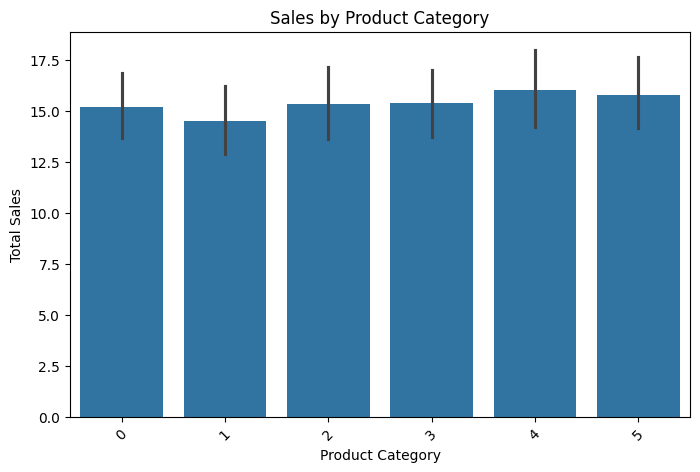

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()

plt.figure(figsize=(8,5))

sns.barplot(
    x='Product line',
    y='gross income',
    data=df
)

plt.xticks(rotation=45)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

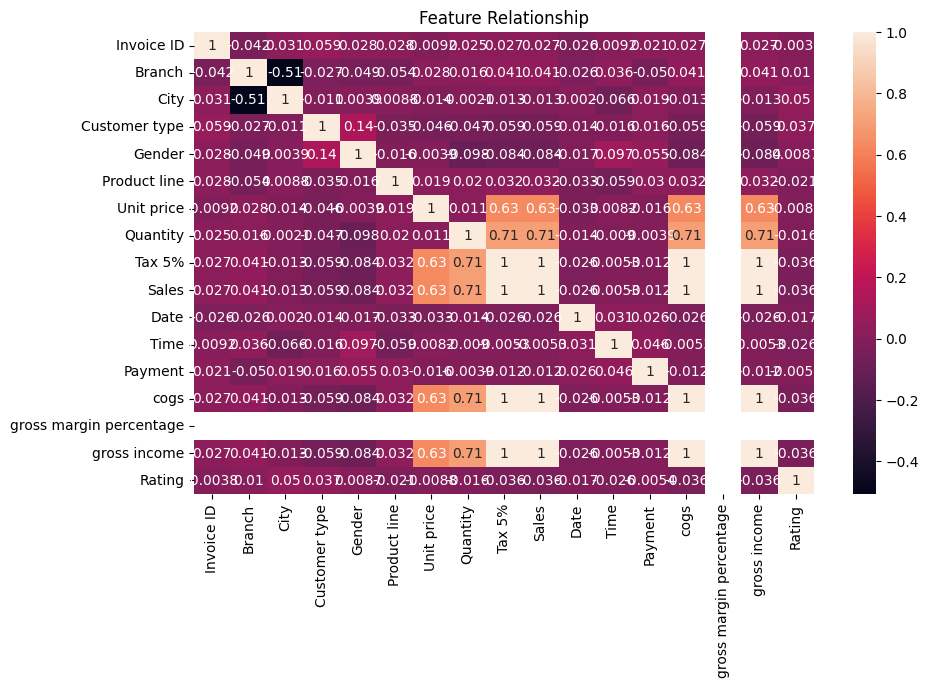

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title("Feature Relationship")
plt.show()

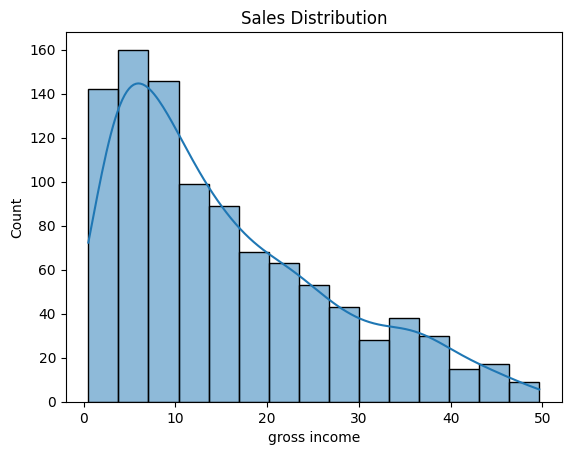

In [24]:
sns.histplot(
    df['gross income'],
    kde=True
)

plt.title("Sales Distribution")
plt.show()

In [25]:
X = df.drop("gross income", axis=1)

In [26]:
y = df["gross income"]

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Sales", axis=1)  

y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 16)
Testing data: (200, 16)


In [28]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [29]:
prediction = model.predict(X_test)

prediction

array([521.60976 , 622.18107 , 408.37608 , 135.972585,  44.75121 ,
       623.450625, 127.862805, 733.153365, 452.2014  , 138.380235,
       423.62733 , 463.33938 , 213.18507 , 252.602385, 290.559885,
       330.124515, 587.00544 , 216.926535, 757.17873 , 185.045805,
       417.68685 , 166.0722  , 128.619435, 125.61591 , 247.28907 ,
       195.74331 , 742.892745,  31.0191  , 145.837965,  56.343105,
        75.580155, 608.415675,  96.15186 , 433.282605, 193.90518 ,
       174.92937 , 665.661465, 198.34899 , 194.25294 , 193.660215,
       214.636695, 922.90569 ,  74.869305, 180.868695,  93.05226 ,
       401.515065, 222.74028 ,  68.80965 , 343.252665, 280.948185,
       430.505985, 101.900505,  69.09924 , 270.42561 , 181.392435,
       492.887535, 462.041265,  60.831855, 456.77919 , 223.097805,
       121.769025,  33.29445 ,  84.835905, 942.849075, 383.37075 ,
       511.109025, 368.936925, 759.848775, 934.87569 , 117.553695,
       390.89169 , 127.838235, 293.308995,  88.83714 ,  65.999

In [30]:
print(
"MAE:",
mean_absolute_error(y_test,prediction)
)

print(
"MSE:",
mean_squared_error(y_test,prediction)
)

print(
"Accuracy:",
r2_score(y_test,prediction)
)

MAE: 0.7732924499999935
MSE: 1.791770147275476
Accuracy: 0.9999724593065881


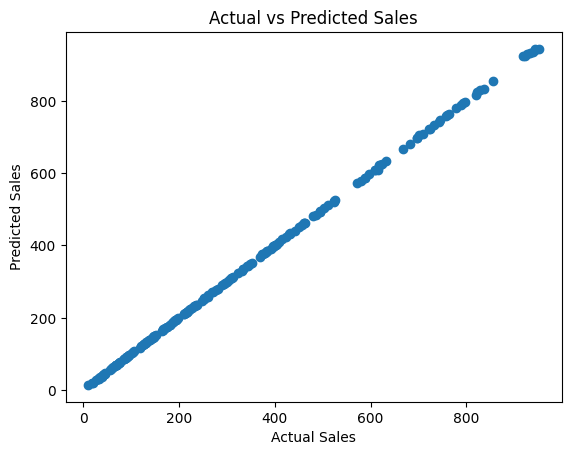

In [31]:
plt.scatter(
    y_test,
    prediction
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
"Actual vs Predicted Sales"
)

plt.show()